In [ ]:
!pip install tensorflow -q
#! — บอก Colab ว่าให้รันคำสั่งนี้เหมือนกับพิมพ์ใน Terminal ไม่ใช่ Python
#pip install — คำสั่งติดตั้ง library
#-q — ย่อมาจาก quiet หมายถึงไม่ต้องแสดงข้อความยาวๆ ระหว่างติดตั้ง

In [ ]:
#from google.colab import drive — โหลดเครื่องมือเชื่อม Google Drive เข้ามา
#drive.mount('/content/drive') — เชื่อม Drive เข้ากับ Colab โดยให้ไฟล์ใน Drive ปรากฏอยู่ที่ path /content/drive


from google.colab import drive
drive.mount('/content/drive')ห


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import Library
#import tensorflow as tf — โหลด TensorFlow ตั้งชื่อย่อว่า tf เพื่อพิมพ์สั้นขึ้น เป็น library หลักสำหรับสร้างและเทรน A
#import os — ใช้จัดการไฟล์และโฟลเดอร์ เช่น อ่านชื่อไฟล์ เช็คว่ามีโฟลเดอร์ไหนบ้าง
#import matplotlib.pyplot as plt — ใช้วาดกราฟและแสดงรูปภาพ ตั้งชื่อย่อว่า plt
#import matplotlib.image as mpimg — ใช้อ่านไฟล์รูปภาพเข้ามาแสดงผล


import tensorflow as tf
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [ ]:
#train_dir — ตัวแปรเก็บ path ของโฟลเดอร์ training_set ที่อัพโหลดไว้ใน Drive
#test_dir — ตัวแปรเก็บ path ของโฟลเดอร์ test_set

train_dir = '/content/drive/MyDrive/Cat-Dog-Datasets/training_set/training_set'
test_dir = '/content/drive/MyDrive/Cat-Dog-Datasets/test_set/test_set'


In [ ]:
import os

# ดูว่า Drive มีอะไรบ้าง
base = '/content/drive/MyDrive'
for item in os.listdir(base):
    print(item)

Project Port
OpenCVrealtime_VisualCode
Cat-Dog-Datasets


In [ ]:
import os

base = '/content/drive/MyDrive/Cat-Dog-Datasets'
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level <= 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

Cat-Dog-Datasets/
  training_set/
    training_set/
      cats/
      dogs/
  test_set/
    test_set/
      cats/
      dogs/


In [ ]:
#os.listdir(...) — อ่านรายชื่อไฟล์ทั้งหมดในโฟลเดอร์นั้น
#test_dir — ตัวแปรเก็บ path ของโฟลเดอร์ test_set
#os.listdir(...) — อ่านรายชื่อไฟล์ทั้งหมดในโฟลเดอร์นั้น
#len(...) — นับจำนวน
#f"..." — f-string ใช้แทรกตัวแปรลงในข้อความโดยใส่ {} ครอบ

print(f"cat-train:  {len(os.listdir(train_dir+'/cats'))} รูป")
print(f"dog-train:  {len(os.listdir(train_dir+'/dogs'))} รูป")
print(f"cat-test:  {len(os.listdir(train_dir+'/cats'))} รูป")
print(f"dog-test:  {len(os.listdir(train_dir+'/dogs'))} รูป")

cat-train:  4001 รูป
dog-train:  4006 รูป
cat-test:  4001 รูป
dog-test:  4006 รูป


/tmp/ipykernel_9919/3701472914.py:20: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3701472914.py:20: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3701472914.py:20: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3701472914.py:20: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3701472914.py:20: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3701472914.py:20: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3701472914.py:20: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans

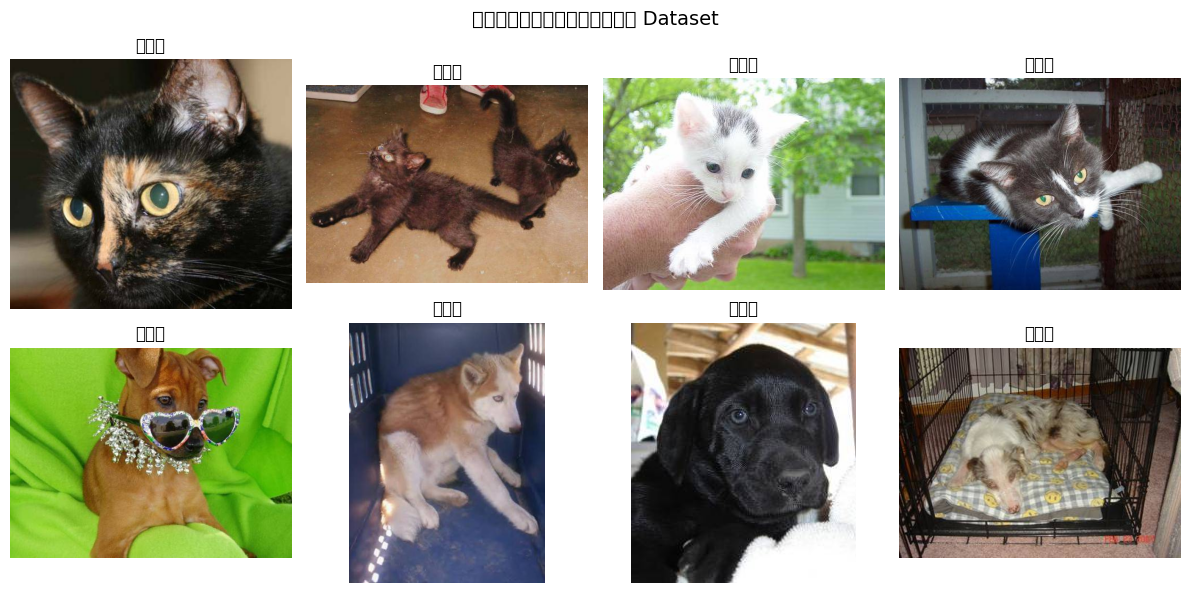

In [ ]:
#Cell 5 — ดูตัวอย่างรูปก่อนเทรน AI ควรดูก่อนว่าข้อมูลที่มีหน้าตาเป็นยังไง รูปชัดไหม ถูกต้องไหม เพื่อให้แน่ใจว่า dataset พร้อมใช้งาน
#enumerate(['cats', 'dogs']) — วนลูปทีละประเภท i=0 คือแมว i=1 คือหมา
#plt.subplots(2, 4) — สร้างตารางรูป 2 แถว 4 คอลัมน์ รวม 8 ช่อง
#os.listdir(folder)[:4] — อ่านชื่อไฟล์ในโฟลเดอร์ แล้วเอาแค่ 4 รูปแรก
#axes[i][j].imshow(img) — แสดงรูปในช่องตาราง
#axes[i][j].axis('off') — ซ่อนแกน x y ออกให้รูปดูสะอาดขึ้น

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, animal in enumerate(['cats', 'dogs']):
    folder = os.path.join(train_dir, animal)
    imgs   = os.listdir(folder)[:4]
    for j, img_name in enumerate(imgs):
        img = mpimg.imread(os.path.join(folder, img_name))
        axes[i][j].imshow(img)
        axes[i][j].set_title('แมว' if animal == 'cats' else 'หมา', fontsize=12)
        axes[i][j].axis('off')

plt.suptitle('ตัวอย่างรูปจาก Dataset', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
#Preprocessing (เตรียมข้อมูล)AI ไม่สามารถรับรูปภาพดิบๆ ได้โดยตรง ต้องแปลงค่าสีให้อยู่ในช่วง 0–1 ก่อน และสร้างรูปเพิ่มด้วยการหมุน พลิก ซูม เพื่อให้ AI เรียนรู้ได้หลากหลายขึ้น
#IMG_SIZE = (224, 224) — resize รูปทุกรูปให้เป็น 224x224 pixel เพราะ MobileNetV2 ต้องการขนาดนี้
#BATCH_SIZE = 32 — โหลดรูปครั้งละ 32 รูป ไม่โหลดทีเดียวหมดเพื่อประหยัด RAM

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# datagen สำหรับชุดเทรน (มี Augmentation)
# rescale=1./255 — แปลงค่าสีจาก 0–255 เป็น 0.0–1.0
# rotation_range=20 — หมุนรูปสุ่มไม่เกิน 20 องศา
# horizontal_flip=True — พลิกรูปซ้าย-ขวาสุ่ม
# zoom_range=0.2 — ซูมเข้า-ออกสุ่มไม่เกิน 20%

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

# datagen สำหรับชุดทดสอบ (ไม่ต้อง Augmentation)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

#zoom_range=0.2 — ซูมเข้า-ออกสุ่มไม่เกิน 20%

val_ds = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print(f"\nชุดเทรน:   {train_ds.samples} รูป")
print(f"ชุดทดสอบ: {val_ds.samples} รูป")
print(f"class indices: {train_ds.class_indices}")

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.

ชุดเทรน:   8005 รูป
ชุดทดสอบ: 2023 รูป
class indices: {'cats': 0, 'dogs': 1}


In [ ]:
""" สร้าง Model เหมือนการออกแบบสมองของ AI ว่าจะมีกี่ชั้น แต่ละชั้นทำหน้าที่อะไร ใช้ MobileNetV2 ที่เทรนมาแล้วมาเป็นฐาน
แล้วเพิ่มชั้นสุดท้ายสำหรับแยกแมว/หมาโดยเฉพาะ"""
#MobileNetV2 — AI ที่ถูกเทรนมาแล้วด้วยรูปภาพกว่า 1 ล้านรูป เราหยิบมาใช้ต่อเลย ไม่ต้องเริ่มจากศูนย์
#input_shape=(224, 224, 3) — รูปขนาด 224x224 และ 3 คือสี RGB (แดง เขียว น้ำเงิน)
#include_top=False — ตัดส่วนหัวของ MobileNetV2 ออก เพื่อเอาไปต่อกับ layer ของเราเอง
#weights='imagenet' — โหลด weight ที่เทรนจากรูป 1 ล้านรูปมาใช้เลย

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

#base_model.trainable = False — แช่แข็ง MobileNetV2 ไว้ก่อน ให้เทรนเฉพาะ layer ที่เราเพิ่มเอง
base_model.trainable = False


#GlobalAveragePooling2D — บีบอัดข้อมูลจากรูปให้เป็นตัวเลขชุดเดียว
#Dropout(0.3) — สุ่มปิด 30% ของ neuron ระหว่างเทรน ป้องกัน AI จำแค่ training data
#Dense(1, activation='sigmoid') — output แค่ 1 ค่า ถ้าใกล้ 0

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

"""optimizer='adam' — อัลกอริธึมปรับ weight ระหว่างเทรน
loss='binary_crossentropy' — วัดว่า AI ทำนายผิดมากแค่ไหน สำหรับ 2 คลาส"""

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()




Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
#เทรน Model
"""ให้ AI ดูรูปภาพทีละ batch แล้วเรียนรู้ว่าอันไหนแมวอันไหนหมา ทำซ้ำหลายรอบ (epochs) จนแม่นขึ้นเรื่อยๆ เหมือนคนเรียนจากตัวอย่างซ้ำๆ จนจำได้"""
#model.fit — สั่งให้ AI เริ่มเรียนรู้จากรูปภาพ
#epochs=10 — ให้ AI ดูรูปทุกรูปครบ 10 รอบ - epochs คือ จำนวนรอบที่ AI ใช้ในการเรียนรู้ข้อมูลชุดเทรน (Training Dataset) จนครบถ้วนทั้งหมด 1 รอบ
#validation_data=val_ds — ทดสอบกับรูปที่ AI ไม่เคยเห็นหลังแต่ละ epoch
#EarlyStopping(patience=3) — ถ้า accuracy ไม่ดีขึ้น 3 epoch ติดต่อกัน หยุดเทรนอัตโนมัติ ประหยัดเวลา
#restore_best_weights=True — เมื่อหยุด ให้โหลด weight ที่ดีที่สุดกลับมา
#verbose=1 — แสดงข้อความเมื่อ EarlyStopping ทำงาน



history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

loss, acc = model.evaluate(val_ds)
print(f"\nความแม่นยำสุดท้าย: {acc:.1%}")

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 790s 3s/step - accuracy: 0.9384 - loss: 0.1577 - val_accuracy: 0.9787 - val_loss: 0.0635
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 643s 3s/step - accuracy: 0.9680 - loss: 0.0837 - val_accuracy: 0.9807 - val_loss: 0.0503
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - accuracy: 0.9718 - loss: 0.0735 - val_accuracy: 0.9817 - val_loss: 0.0474
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 645s 3s/step - accuracy: 0.9741 - loss: 0.0650 - val_accuracy: 0.9827 - val_loss: 0.0458
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 598s 2s/step - accuracy: 0.9735 - loss: 0.0685 - val_accuracy: 0.9857 - val_loss: 0.0449
Restoring model weights from the end of the best epoch: 5.
64/64 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9857 - loss: 0.0449

ความแม่นยำสุดท้าย: 98.6%


/tmp/ipykernel_9919/3245075610.py:22: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3245075610.py:22: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3245075610.py:22: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3245075610.py:22: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3245075610.py:22: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3245075610.py:22: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9919/3245075610.py:22: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu San

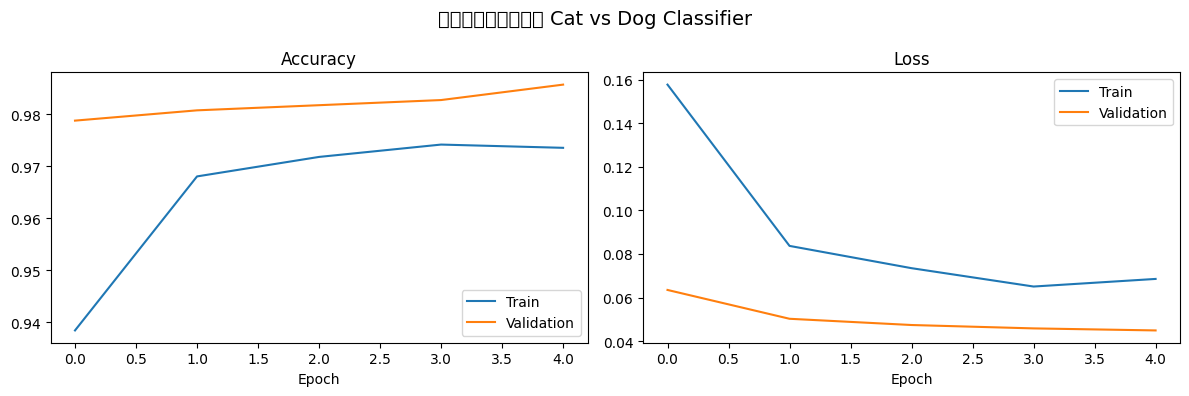

In [37]:
"""ดูกราฟผลการเทรน ดูว่า AI เรียนรู้ได้ดีแค่ไหนในแต่ละรอบ
ถ้ากราฟขึ้นเรื่อยๆ แปลว่าดี ถ้า Train สูงแต่ Validation ต่ำ แปลว่า AI จำแค่ training data แต่ไม่เข้าใจรูปใหม่"""

"""เส้น Train และ Validation ขึ้นพร้อมกัน → AI เรียนรู้ได้ดี
ถ้า Train สูงมากแต่ Validation ต่ำ → AI จำ training data มากเกินไป (Overfitting)"""

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('ผลการเทรน Cat vs Dog Classifier', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cat-Dog-Datasets/training_history.png')
plt.show()

In [38]:
""" บันทึก Model เซฟ AI ที่เทรนเสร็จแล้วเก็บไว้ใน Google Drive เพื่อเอาไปใช้ต่อได้โดยไม่ต้องเทรนใหม่"""
#model.save — บันทึก AI ที่เทรนเสร็จแล้วเก็บไว้ใน Drive ไม่ต้องเทรนใหม่ทุกครั้ง

model.save('/content/drive/MyDrive/Cat-Dog-Datasets/cat_dog_model.keras')
print("บันทึก model เรียบร้อย!")

บันทึก model เรียบร้อย!


In [40]:
"""ทดสอบกับรูปใหม่ อัพโหลดรูปแมวหรือหมาของตัวเองมา แล้วให้ AI ทายว่าเป็นอะไร พร้อมแสดง % ความมั่นใจ"""

from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    img  = image.load_img(img_path, target_size=(224, 224))
    arr  = image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)[0][0]

    label = 'หมา ' if pred > 0.5 else 'แมว '
    conf  = pred if pred > 0.5 else 1 - pred

    plt.imshow(image.load_img(img_path))
    plt.title(f'ผล: {label}  ความมั่นใจ: {conf:.1%}', fontsize=14)
    plt.axis('off')
    plt.show()
    print(f'ผล: {label}  ความมั่นใจ: {conf:.1%}')

# อัพโหลดรูปมาทดสอบได้เลย!
from google.colab import files
uploaded = files.upload()
for fname in uploaded:
    predict_image(fname)

Output hidden; open in https://colab.research.google.com to view.